# 멀티모달 대규모 언어 모델

- 모달리티(데이터의 유형, 형태)라고 부르는 텍스트와 이미지를 다룰 수 있는 모델을 멀티모달이라 부릅니다.
- 이미지, 오디오, 비디오, 센서 데이터와 같이 여러 종류(모달리티)의 데이터를 다룰 수 있는 모델을 멀티모달이라 부릅니다. 한 모달리티를 입력을 받을 수 있지만 행당 모달리티로 출력을 생성하지 못할 수 있습니다.


## 비전 트랜스포머

- 비전 트랜스포머(ViT)는 합성곱 신경망(CNN)에 비해 이미지 인식 작업에서 매우 잘 동작한다는 것이 입증되었습니다.
- https://arxiv.org/abs/2010.11929
- 원본 트랜스포머처럼 ViT를 사용해 비정형 데이터인 이미지를 분류와 같은 다양한 작업에 사용할 수 있는 표현으로 바꿀수 있습니다.
- ViT 트랜스포머 구조의 핵심 구성요소인 인코더에 의존합니다.
- 인코더는 텍스트 입력을 디코더에 전달하기 전에 수치 표현으로 바꾸는 역할을 합니다.
- 하지만 인코더가 제 역할을 수행하기 전에 텍스트 입력이 먼저 토큰으로 바뀌어야 합니다.


- 이미지는 단어로 구성되지 않았기 때문에 토큰화 단계를 비전 데이터에 사용할 수 없습니다.
- 대신 ViT 저자들은 이미지를 '단어'로 토큰화하는 방법을 만들었습니다.
- 이를 통해 원본 인코더 구조를 사용할 수 있습니다.


- 고양이 이미지가 있다고 가정해보죠.
- 이 이미지는 여러 개의 픽셀로 표현됩니다.
- 예를 들어 512x512 픽셀 이미지가 있다고 가정해봅시다.
- 각 개별 픽셀은 많은 정보를 담고 있지 않지만 픽셀의 패치를 연결하면 점차 더 많은 정보가 드러나기 시작합니다.


- ViT는 이와 유사한 원리를 사용합니다.
- 텍스트를 토큰으로 분할하는 것처럼 원본 이미지를 이미지 패치로 변환합니다.
- 이미지를 수평과 수직 방향으로 여러개의 조각으로 자릅니다.


- 텍스트를 토큰으로 변환하는 걱처럼 이미지를 이미지의 패치로 바꿉니다.
- 이미지 패치를 펼친 입력을 텍스트에 있는 토큰으로 생각할 수 있습니다.
- 하지만 각 패치에 고유한 ID를 할당할 수 없습니다.
- 텍스트 어휘사전에 있는 토큰과 달리 이런 패치는 다른 이미지에 나타나는 경우가 거의 없기 때문입니다.


- 그 대신 패치를 선형적으로 임베딩하여 수치 표현, 즉 임베딩을 만듭니다.
- 이를 트랜스포머 모델의 입력으로 사용합니다.
- 이런 식으로 이미지 패치를 토큰과 동일한 방식으로 다룹니다.


- 원본 ViT 모델은 16x16크기의 패치를 사용합니다.
- 이 방식에서 흥미로운 점은 이 임베딩이 인코더로 전달되면 텍스트 토큰처럼 처리된다는 것입니다.
- 이 시점부터 텍스트와 이미지를 훈련하는 방식에 차이가 없습니다.
- 이런 유사성으로 인해 ViT를 온갖 종류의 언어 모델을 멀티모달로 만드는 데 사용합니다.
- 이를 사용하는 매우 간단한 방법 하나는 임베딩 모델의 훈련 과정에 추가하는 것입니다.
- ViT 구현은 이미지 패치를 직접 나누고 밀집 층을 사용해 임베딩을 만듭니다. 요즘 비전 트랜스포머 모델은 필터와 스트라이드가 패치 크기와 같고 출력 채널이 임베딩 크기와 같은 합성곱 층을 사용하여 패치 임베딩을 만드는 경우가 많습니다.


## 멀티모달 임베딩 모델

- 멀티모달 임베딩 모델은 동일한 벡터 공간 안에 여러 모달리티를 위한 임베딩을 만들수 있습니다.
- 만들어진 임베딩이 동일한 벡터 공간에 놓이기 때문에 멀티모달 표현을 비교할 수 있다는 것이 장점입니다.
- 예를들면 멀티모달 임베딩 모델을 사용하면 입력 텍스트를 기반으로 이미지를 찾을 수 있습니다.
- 이는 질문과 관련성이 가장 높은 문서를 찾는 작업과 비슷합니다.
- 멀티모달 임베딩 모델이 많지만 가장 유명하고 널리 사용되는 모델은 CLIP(Contrastive Language-Image Pre-training)입니다.


### CLIP: 텍스트와 이미지 연결

- CLIP은 이미지와 텍스트 임베딩을 모두 계산할 수 있는 임베딩 모델입니다.
- 만들어진 임베딩은 동일한 벡터 공간에 놓입니다.
- 이미지 임베딩을 텍스트 임베딩과 비교할 수 있다는 의미입니다.
- 제로샷 분류: 이미지 임베딩을 후보 클래스 설명의 임베딩과 비교하여 가장 비슷한 클래스를 찾을 수 있습니다.
- 클러스터링: 키워드가 어떤 이미지 집합에 속하는지 찾기 위해 이미지와 키워드 집합을 클러스터로 모읍니다.
- 검색: 수십억 개의 텍스트 또는 이미지에서 입력 텍스트나 이미지에 관련된 결과를 빠르게 찾습니다.
- 생성: 이미지 생성(예를 들어 스테이블 디퓨전)에 멀티모달 임베딩을 사용합니다.


### CLIP이 멀티모달 임베딩을 생성하는 방법

- CLIP의 작동 방식은 실제로 매우 간단합니다.
- 수백만 개의 이미지와 캡션으로 구성된 데이터셋이 있다고 상상해보죠
- 이 데이터셋을 사용해 이미지와 캡션에 대해 2개의 표현을 만들 수 있습니다.
- 이를 위해 CLIP은 텍스트 인코더를 사용해 텍스트를 임베딩하고 이미지 인코더를 사용해 이미지를 임베딩합니다.
- 생성된 임베딩 쌍을 코사인 유사도로 비교합니다.
- 훈련을 시작할 때 이미지 임베딩과 텍스트 임베딩 사이의 유사도는 매우 낮습니다.
- 훈련하는 동안 두 임베딩 사이의 유사도를 최적화합니다.
- 이방법을 대조학습이라 부릅니다.


### OpenCLIP

- https://github.com/mlfoundations/open_clip
- OpenCLIP 또는 다른 어떤 CLIP 모델을 사용한다는 것은 텍스트 입력과 이미지 입력을 처리하여 메인 모델로 보낸다는 의미입니다.


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

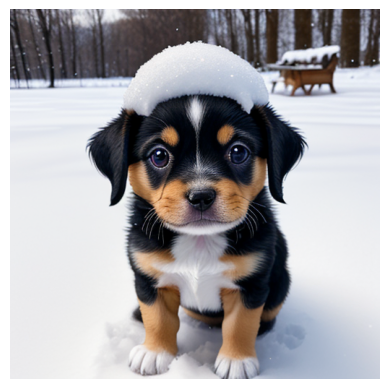

In [32]:
from urllib.request import urlopen
from PIL import Image
import matplotlib.pyplot as plt

puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image = Image.open(urlopen(puppy_path)).convert("RGB")

caption = "a puppy playing in the snow"

# 전처리된 이미지를 출력합니다.
plt.imshow(image)
plt.axis("off")

- 이 이미지의 캡션이 있으므로 OpenCLIP을 사용해 이미지와 텍스트의 임베딩을 모두 생성할 수 있습니다.
- 이를 위해 3개의 모델을 로드해야 합니다.
  - 텍스트 입력을 토큰화하기 위한 토크나이저
  - 이미지를 전처리하고 크기를 바꾸기 위한 전처리기
  - 위의 두 출력을 임베딩으로 바꾸는 메인 모델

- 허깅 페이스 transformers 라이브러리에서 제공하는 ~TokenizerFast 클래스는 러스트로 작성된 허깅 페이스의 tokenizer 라이브러리 기반으로 구현되었으며 파이썬 버전인 ~Tokenizer 클래스보다 성능이 뛰어납니다.
- 사실 CLIPProcessor가 CLIPTokenizerFast를 사용해 토큰화를 수행할 수 있기 때문에 토크나이저를 따로 로드할 필요는 없습니다.


In [ ]:
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel
model_id = "openai/clip-vit-base-patch32"

# 텍스트 전처리를 위한 토크나이저를 로드합니다.
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id)

# 이미지 전처리를 위한 전처리기를 로드합니다.
clip_processor = CLIPProcessor.from_pretrained(model_id)

# 텍스트 임베딩과 이미지 임베딩을 생성하기 위한 메인 모델
model = CLIPModel.from_pretrained(model_id)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1909.41it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# 입력을 토큰으로 나눕니다.
inputs = clip_tokenizer(caption, return_tensors="pt")
inputs

{'input_ids': tensor([[49406,   320,  6829,  1629,   530,   518,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

- 이 출력은 입력 ID를 담고 있는 딕셔너리 입니다.
- 이 ID가 무엇을 나타내는지 확인하기 위해 convert_ids_to_tokens 함수를 사용해 ID를 토큰으로 바꿀수 있습니다.


In [5]:
# 입력 ID를 토큰으로 되돌립니다.
clip_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

['<|startoftext|>',
 'a</w>',
 'puppy</w>',
 'playing</w>',
 'in</w>',
 'the</w>',
 'snow</w>',
 '<|endoftext|>']

- 이전에 자주 보았듯이 텍스트는 토큰으로 분할됩니다.
- 이미지 임베딩과 구분되도록 텍스트의 시작과 끝 토큰이 추가되었습니다.
- 결과중에 [CLS] 토큰이 없다는 것도 볼수 있습니다.
- CLIP에서 [CLS] 토큰은 이미지 임베딩을 표현하는데 사용됩니다.
  - CLIP 모델은 텍스트의 경우 마지막 토큰(EOS)의 임베딩을 사용하고, 이미지의 경우 첫번째 토큰(CLS)의 임베딩을 사용합니다.


In [44]:
# 텍스트 임베딩을 만듭니다.
text_embedding= model.get_text_features(**inputs)
text_embedding_tensor = text_embedding.pooler_output
print(text_embedding_tensor.shape)

torch.Size([1, 512])


- 하나의 문자열에 대한 임베딩 결과는 512개의 값입니다.
- 이미지 임베딩을 만들기 전에 텍스트 임베딩을 만들 때처럼 전처리해야 합니다.
- 모델이 크기와 같은 속성을 가진 텐서 형태의 이미지를 기대하기 때문입니다.
- 이를 위해 앞서 로드한 clip_processor를 사용합니다.
  - 이와 비슷하게 다음처럼 text 매개변수에 캡션을 전달하여 토큰화를 수행할 수 있습니다.
  - inputs = clip_processor(text=caption, return_tensors='pt')


In [40]:
import torch
import numpy as np

# 이미지를 전처리합니다.
processed_image = clip_processor(
    text=None, images=image, return_tensors="pt"
)["pixel_values"]

print(processed_image.shape)

torch.Size([1, 3, 224, 224])


- 원본 이미지 크기는 512x512 픽셀 입니다. 전처리하여 모델이 기대하는 224x224 크기로 줄였습니다.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

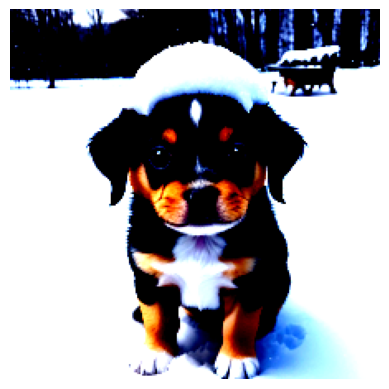

In [41]:
# matplotlib의 imshow는 (높이, 너비, 채널) 또는 (너비, 높이, 채널) 순서를 기대합니다.
# 따라서 차원 순서를 바꿔줘야 올바르게 이미지를 시각화할 수 있습니다.

import torch
import numpy as np
import matplotlib.pyplot as plt

# 시각화를 이해 이미지를 준비합니다.
# 첫번째 차원(크기 1)을 제거하여 3차원 텐서(채널, 높이, 너비)로 만듭니다.
img = processed_image.squeeze(0)

# 텐서의 차원 순서를 뒤집습니다. 예를들어 C,H,W -> W, H, C
# torch.arange는 2,1,0 처럼 역순 인덱스를 만듭니다.
img = img.permute(*torch.arange(img.ndim - 1, -1, -1))

# 차원순서를 (i,j,k) -> (j,i,k)로 바꿉니다.
# 첫번째와 두번째 차원을 맞바꿉니다. (W, H, C) -> (H, W, C)로 변환됩니다.
img = np.einsum("ijk->jik", img)

# # 전처리된 이미지를 출력합니다.
plt.imshow(img)
plt.axis("off")

- 전처리된 이미지를 임베딩으로 변환하려면 이전처럼 모델을 호출해야 합니다.


In [45]:
# 이미지 임베딩을 만듭니다.
image_embedding = model.get_image_features(processed_image)
image_embedding_tensor = image_embedding.pooler_output
print(image_embedding_tensor.shape)

torch.Size([1, 512])


- 이미지 임베딩의 크기가 텍스트 임베딩의 크기와 같습니다.
- 두 임베딩을 비교하고 비슷한지 확인할 수 있기 때문에 크기가 같다는 사실은 중요합니다.
- 두 임베딩을 사용해 얼마나 비슷한지 계산할 수 있습니다.


In [47]:
# 임베딩을 정규화합니다.
text_embedding_tensor /= text_embedding_tensor.norm(dim=-1, keepdim=True)
image_embedding_tensor /= image_embedding_tensor.norm(dim=-1, keepdim=True)

# 유사도를 계산합니다.
text_embedding_tensor = text_embedding_tensor.detach().cpu().numpy()
image_embedding_tensor = image_embedding_tensor.detach().cpu().numpy()
score = np.dot(text_embedding_tensor, image_embedding_tensor.T)
score

array([[0.3314964]], dtype=float32)

- 0.33이란 유사도 점수를 해석하기 어렵습니다.
- 모델이 생각하는 낮은 유사도 점수와 높은 유사도 점수에 대해 알지 못하기 때문입니다.
- 이 모델의 경우 0.33은 높은 점수 입니다.


### sentence-transformers를 사용해 CLIP 로드하기

- sentence-transformers는 임베딩을 훨씬 쉽게 만들 수 있는 CLIP 기반 모델을 몇 개 제공합니다.


In [ ]:
from sentence_transformers import SentenceTransformer, util

# SBERT 호환 CLIP 모델을 로드합니다.
model = SentenceTransformer("clip-ViT-B-32")

# 이미지를 인코딩합니다.
image_embeddings = model.encode(image)

# 캡션을 인코딩합니다.
text_embeddings = model.encode(caption)

#코사인 유사도를 계산합니다.
sim_matrix = util.cos_sim(image_embeddings, text_embeddings)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1661.44it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: C:\Users\bbang\.cache\huggingface\hub\models--sentence-transformers--clip-ViT-B-32\snapshots\327ab6726d33c0e22f920c83f2ff9e4bd38ca37f\0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [50]:
print(sim_matrix)

tensor([[0.3315]])
